<a href="https://colab.research.google.com/github/RodrigoGutV/ciencia-de-dato-s9/blob/main/ciencia_datos_S9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Punto 2 - Elaboracion de Scrip

In [ ]:
import pandas as pd
#A-CARGA DEL ARCHIVO CSV
df = pd.read_csv(
    "moviciudad_operaciones_bruto_SET_A.csv"
)

#B-EXPLORACIÓN INICIAL
print("Primeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

#C-LIMPIEZA DE DATOS
# Eliminar duplicados
df = df.drop_duplicates()

# Normalizar nombres de columnas
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

# Normalizar texto
if "recorrido" in df.columns:
    df["recorrido"] = (
        df["recorrido"]
        .astype(str)
        .str.upper()
        .str.strip()
    )
# Conversión de fechas
if "fecha" in df.columns:
    df["fecha"] = pd.to_datetime(
        df["fecha"],
        errors="coerce"
    )

# Conversión numérica
if "tiempo_viaje" in df.columns:
    df["tiempo_viaje"] = pd.to_numeric(
        df["tiempo_viaje"],
        errors="coerce"
    )

#D-TRATAMIENTO DE VALORES NULOS
if "tiempo_viaje" in df.columns:
    df["tiempo_viaje"] = (
        df["tiempo_viaje"]
        .fillna(df["tiempo_viaje"].median())
    )

#Eliminar filas sin recorrido
if "recorrido" in df.columns:
    df = df.dropna(subset=["recorrido"])

#E-VALIDACIÓN DE DATOS
if "tiempo_viaje" in df.columns:
    df = df[df["tiempo_viaje"] > 0]

#F-ESTRUCTURACIÓN
df = df.reset_index(drop=True)

#G-VARIABLES DERIVADAS
if "fecha" in df.columns:
    df["hora"] = df["fecha"].dt.hour

#Indicador de congestión
if "tiempo_viaje" in df.columns:
    df["congestion"] = (
        df["tiempo_viaje"] > 60
    )

# H-EXPORTAR DATOS LIMPIOS
df.to_csv(
    "moviciudad_operaciones_limpio.csv",
    index=False
)

print("\nProceso completado correctamente.")
print("Archivo limpio generado.")

Primeras filas:
  id_formulario fecha_registro hora_salida  ruta   turno tipo_dia  \
0        F10000     2025-11-07       13:22  R-06   Tarde    Hábil   
1        F10001     2025-11-20       17:46  R-03  Mañana    Hábil   
2        F10002     2025-11-29       11:37  R-01  Mañana    Hábil   
3        F10003     2025-11-15       19:30  R-03  Mañana    Hábil   
4        F10004     2025-11-11       18:14  R-05  Mañana    Hábil   

  tiempo_viaje_min retraso_min  pasajeros_reportados  
0             35.3        -0.2                  74.0  
1             40.5        12.1                  10.0  
2             23.3         5.1                  16.0  
3             66.0        10.9                   9.0  
4             27.6         4.8                  25.0  

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_for

Punto 3

Columnas del archivo:
Index(['id_formulario', 'fecha_registro', 'hora_salida', 'ruta', 'turno',
       'tipo_dia', 'tiempo_viaje_min', 'retraso_min', 'pasajeros_reportados'],
      dtype='object')

=== ESTADÍSTICA DESCRIPTIVA ===
count    173.000000
mean      42.567630
std       19.890593
min       12.000000
25%       33.200000
50%       40.700000
75%       51.100000
max      240.000000
Name: tiempo_viaje_min, dtype: float64


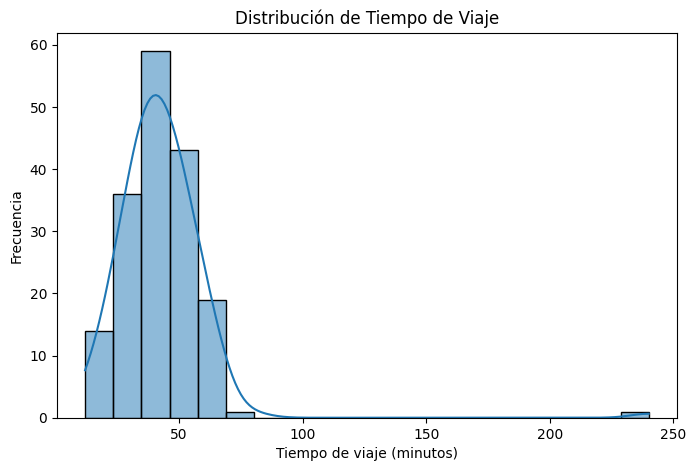

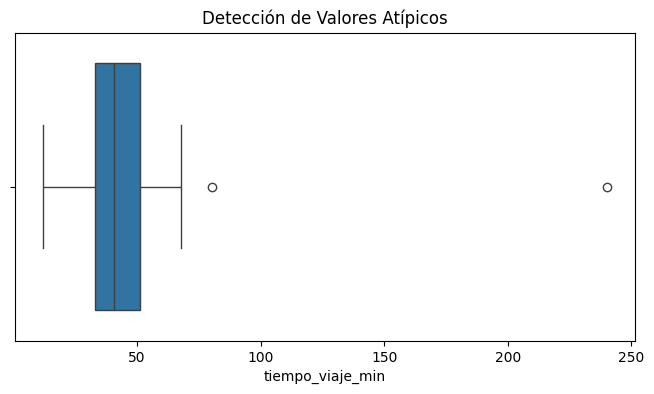

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================
# 1. CARGAR ARCHIVO CSV
# ======================================

df = pd.read_csv(
    "moviciudad_operaciones_bruto_SET_A.csv"
)

# ======================================
# 2. MOSTRAR COLUMNAS
# ======================================

print("Columnas del archivo:")
print(df.columns)

# ======================================
# 3. SELECCIONAR COLUMNA A ANALIZAR
# ======================================

columna = "tiempo_viaje_min"

# Convertir a número
df[columna] = pd.to_numeric(
    df[columna],
    errors="coerce"
)

# Eliminar valores nulos
df = df.dropna(subset=[columna])

# ======================================
# 4. ESTADÍSTICA DESCRIPTIVA
# ======================================

print("\n=== ESTADÍSTICA DESCRIPTIVA ===")

print(df[columna].describe())

# ======================================
# 5. HISTOGRAMA
# ======================================

plt.figure(figsize=(8,5))

sns.histplot(
    df[columna],
    bins=20,
    kde=True
)

plt.title(
    "Distribución de Tiempo de Viaje"
)

plt.xlabel("Tiempo de viaje (minutos)")
plt.ylabel("Frecuencia")

plt.show()

# ======================================
# 6. BOXPLOT
# ======================================

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df[columna]
)

plt.title(
    "Detección de Valores Atípicos"
)

plt.show()

Punto 4

Columnas detectadas:
Index(['id_formulario', 'fecha_registro', 'hora_salida', 'ruta', 'turno',
       'tipo_dia', 'tiempo_viaje_min', 'retraso_min', 'pasajeros_reportados'],
      dtype='object')

=== ESTADÍSTICA DESCRIPTIVA ===
       tiempo_viaje_min  retraso_min  pasajeros_reportados
count        148.000000   148.000000            148.000000
mean          42.893243     4.997297             46.331081
std           21.075968    11.296402             81.197784
min           12.000000   -10.000000              0.000000
25%           32.475000    -0.100000             26.000000
50%           40.900000     4.600000             39.000000
75%           51.425000     8.700000             55.000000
max          240.000000   120.000000            999.000000


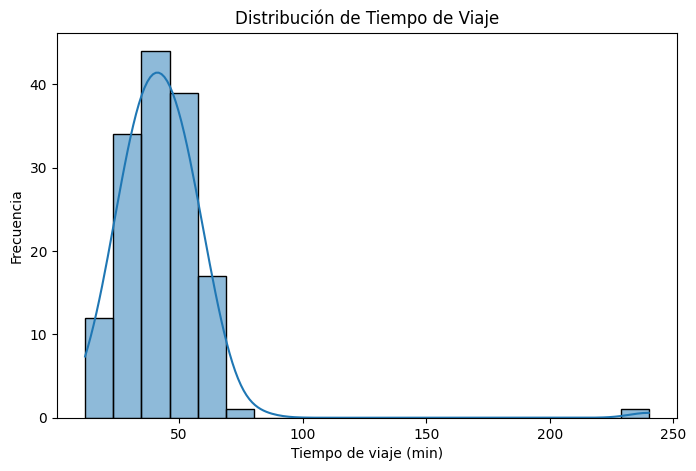

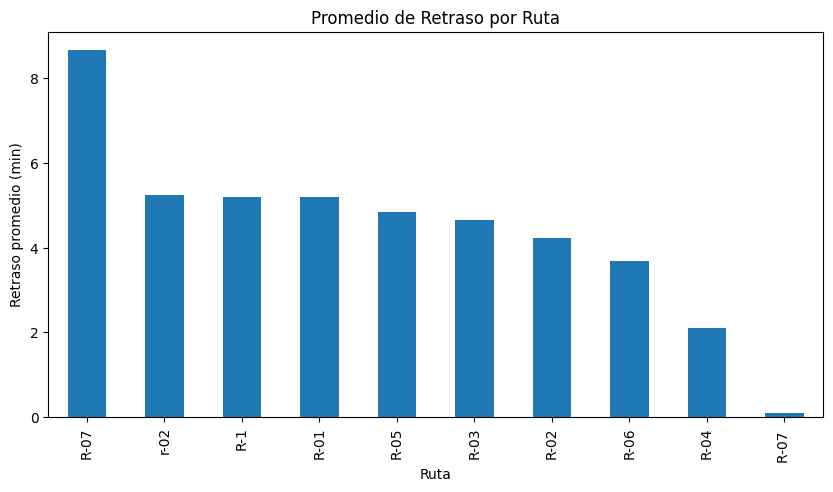


Archivo Excel exportado correctamente.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================
# 1. CARGAR ARCHIVO CSV
# ======================================

df = pd.read_csv(
    "moviciudad_operaciones_bruto_SET_A.csv"
)

# ======================================
# 2. NORMALIZAR COLUMNAS
# ======================================

df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

print("Columnas detectadas:")
print(df.columns)

# ======================================
# 3. LIMPIEZA BÁSICA
# ======================================

# Convertir columnas numéricas
columnas_numericas = [
    "tiempo_viaje_min",
    "retraso_min",
    "pasajeros_reportados"
]

for col in columnas_numericas:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Eliminar valores nulos
df = df.dropna()

# Eliminar duplicados
df = df.drop_duplicates()

# ======================================
# 4. ESTADÍSTICA DESCRIPTIVA
# ======================================

print("\n=== ESTADÍSTICA DESCRIPTIVA ===")

print(
    df[columnas_numericas].describe()
)

# ======================================
# 5. DASHBOARD - GRÁFICO 1
# HISTOGRAMA TIEMPO DE VIAJE
# ======================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["tiempo_viaje_min"],
    bins=20,
    kde=True
)

plt.title(
    "Distribución de Tiempo de Viaje"
)

plt.xlabel("Tiempo de viaje (min)")
plt.ylabel("Frecuencia")

plt.show()

# ======================================
# 6. DASHBOARD - GRÁFICO 2
# PROMEDIO DE RETRASO POR RUTA
# ======================================

promedio_ruta = (
    df.groupby("ruta")["retraso_min"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

promedio_ruta.plot(
    kind="bar"
)

plt.title(
    "Promedio de Retraso por Ruta"
)

plt.xlabel("Ruta")
plt.ylabel("Retraso promedio (min)")

plt.show()

# ======================================
# 7. EXPORTAR DATASET LIMPIO A EXCEL
# ======================================

df.to_excel(
    "moviciudad_operaciones_procesado.xlsx",
    index=False
)

print("\nArchivo Excel exportado correctamente.")

Punto 5

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# 1. CARGAR DATOS


df = pd.read_csv(
    "moviciudad_operaciones_bruto_SET_A.csv"
)


# 2. LIMPIEZA BÁSICA


df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

# Convertir columnas numéricas
columnas = [
    "retraso_min",
    "pasajeros_reportados",
    "tiempo_viaje_min"
]

for col in columnas:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Eliminar valores nulos
df = df.dropna()


# 3. VARIABLES DEL MODELO
X = df[
    [
        "retraso_min",
        "pasajeros_reportados"
    ]
]

y = df["tiempo_viaje_min"]

# 4. DIVIDIR DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 5. ENTRENAR MODELO
modelo = LinearRegression()

modelo.fit(
    X_train,
    y_train
)

# 6. REALIZAR PREDICCIONES
predicciones = modelo.predict(X_test)

# 7. MÉTRICAS
mae = mean_absolute_error(
    y_test,
    predicciones
)
mse = mean_squared_error(
    y_test,
    predicciones
)
print("\n=== RESULTADOS DEL MODELO ===")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")


=== RESULTADOS DEL MODELO ===
MAE: 17.95
MSE: 1496.44
